In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("heart_disease_uci.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.shape

(920, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    object 
 6   restecg   918 non-null    object 
 7   thalch    865 non-null    float64
 8   exang     865 non-null    object 
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    object 
 11  ca        309 non-null    float64
 12  thal      434 non-null    object 
 13  target    920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


In [5]:
df.isnull().sum()/len(df)*100.00

age          0.000000
sex          0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
target       0.000000
dtype: float64

In [6]:
# Numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [7]:
cat_cols = df.select_dtypes(include=["object"]).columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

C:\Users\Acer.DESKTOP-OGQID04\AppData\Local\Temp\ipykernel_7144\549759147.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.dtypes

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object

In [10]:
categorical_cols = ["cp", "restecg", "slope", "thal"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [11]:
df.dtypes
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [12]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,Male,145.0,233.0,True,150.0,False,2.3,0.0,0,False,False,True,False,False,False,False,False,False
1,67,Male,160.0,286.0,False,108.0,True,1.5,3.0,2,False,False,False,False,False,True,False,True,False
2,67,Male,120.0,229.0,False,129.0,True,2.6,2.0,1,False,False,False,False,False,True,False,False,True
3,37,Male,130.0,250.0,False,187.0,False,3.5,0.0,0,False,True,False,True,False,False,False,True,False
4,41,Female,130.0,204.0,False,172.0,False,1.4,0.0,0,True,False,False,False,False,False,True,True,False


In [13]:
df["sex"] = df["sex"].map({"Male": 1, "Female": 0})


In [14]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,True,150.0,False,2.3,0.0,0,False,False,True,False,False,False,False,False,False
1,67,1,160.0,286.0,False,108.0,True,1.5,3.0,2,False,False,False,False,False,True,False,True,False
2,67,1,120.0,229.0,False,129.0,True,2.6,2.0,1,False,False,False,False,False,True,False,False,True
3,37,1,130.0,250.0,False,187.0,False,3.5,0.0,0,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,False,172.0,False,1.4,0.0,0,True,False,False,False,False,False,True,True,False


In [15]:
df.dtypes
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [16]:
bool_cols = df.select_dtypes(include=["bool"]).columns

df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,2,0,0,0,0,0,1,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,0,0,0,0,0,1,0,0,1
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,0,1,0,1,0,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,1,0,0,0,0,0,1,1,0


In [18]:
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [19]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,2,0,0,0,0,0,1,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,0,0,0,0,0,1,0,0,1
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,0,1,0,1,0,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,1,0,0,0,0,0,1,1,0


In [20]:
df.dtypes

age                           int64
sex                           int64
trestbps                    float64
chol                        float64
fbs                           int64
thalch                      float64
exang                         int64
oldpeak                     float64
ca                          float64
target                        int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_normal                int64
restecg_st-t abnormality      int64
slope_flat                    int64
slope_upsloping               int64
thal_normal                   int64
thal_reversable defect        int64
dtype: object

In [21]:
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [22]:
df.describe()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,131.995652,199.908696,0.150000,137.692391,0.366304,0.853261,0.227174,0.995652,0.189130,0.221739,0.050000,0.601087,0.194565,0.710870,0.220652,0.741304,0.208696
std,9.424685,0.408148,18.451300,109.040171,0.357266,25.145235,0.482056,1.058049,0.628936,1.142693,0.391825,0.415642,0.218063,0.489941,0.396081,0.453605,0.414912,0.438156,0.406597
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,177.750000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,140.000000,0.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
df["target"].value_counts()

target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [24]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [25]:
df["target"].value_counts()


target
1    509
0    411
Name: count, dtype: int64

In [26]:
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [27]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,0,0,0,0,0,1,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,0,0,0,0,0,1,0,0,1
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,0,1,0,1,0,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,1,0,0,0,0,0,1,1,0


In [28]:
df.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
ca                          0
target                      0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
slope_flat                  0
slope_upsloping             0
thal_normal                 0
thal_reversable defect      0
dtype: int64

In [29]:
df.dtypes

age                           int64
sex                           int64
trestbps                    float64
chol                        float64
fbs                           int64
thalch                      float64
exang                         int64
oldpeak                     float64
ca                          float64
target                        int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_normal                int64
restecg_st-t abnormality      int64
slope_flat                    int64
slope_upsloping               int64
thal_normal                   int64
thal_reversable defect        int64
dtype: object

In [30]:
df.value_counts()

age  sex  trestbps  chol   fbs  thalch  exang  oldpeak  ca   target  cp_atypical angina  cp_non-anginal  cp_typical angina  restecg_normal  restecg_st-t abnormality  slope_flat  slope_upsloping  thal_normal  thal_reversable defect
49   0    110.0     223.0  0    160.0   0      0.0      0.0  0       1                   0               0                  1               0                         1           0                1            0                         2
58   1    150.0     219.0  0    118.0   1      0.0      0.0  1       0                   1               0                  0               1                         1           0                1            0                         2
35   0    120.0     160.0  0    185.0   0      0.0      0.0  0       0                   0               1                  0               1                         1           0                1            0                         1
72   1    160.0     223.0  1    130.0   0      1.5      0.0  

In [31]:
df["oldpeak"].value_counts()

oldpeak
 0.0    370
 1.0     83
 0.5     81
 2.0     76
 1.5     48
 3.0     28
 1.2     17
 2.5     16
 0.8     15
 1.4     15
 0.6     14
 0.2     14
 1.6     14
 1.8     12
 0.4     10
 0.1      9
 4.0      8
 2.6      7
 2.8      7
 2.2      5
 1.3      5
 0.3      5
 0.7      5
 1.9      5
 1.1      4
 3.6      4
 2.4      4
 0.9      4
 3.4      3
-0.5      2
 3.2      2
 2.3      2
 3.5      2
 1.7      2
-1.0      2
 4.2      2
 2.1      2
 3.1      1
 2.9      1
 6.2      1
 5.6      1
 3.8      1
-1.1      1
 4.4      1
 5.0      1
-2.6      1
-0.1      1
-1.5      1
-2.0      1
-0.7      1
-0.8      1
-0.9      1
 3.7      1
Name: count, dtype: int64

In [32]:
df.describe()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,131.995652,199.908696,0.150000,137.692391,0.366304,0.853261,0.227174,0.553261,0.189130,0.221739,0.050000,0.601087,0.194565,0.710870,0.220652,0.741304,0.208696
std,9.424685,0.408148,18.451300,109.040171,0.357266,25.145235,0.482056,1.058049,0.628936,0.497426,0.391825,0.415642,0.218063,0.489941,0.396081,0.453605,0.414912,0.438156,0.406597
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,177.750000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,140.000000,0.000000,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

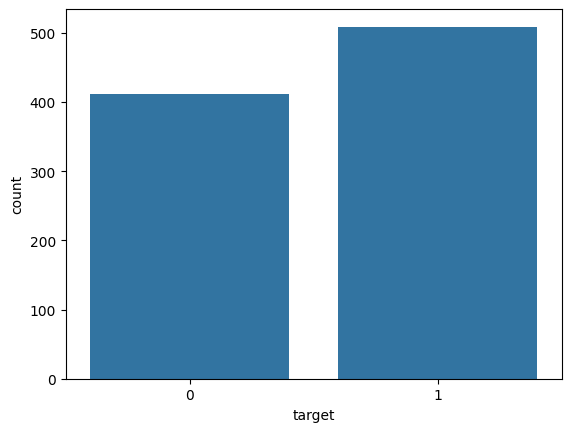

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.show()

## 🧠 Interview me agar pooche

##Why countplot for target?


##To check class distribution and detect class imbalance in the dataset.

age
54    51
58    43
55    41
56    38
57    38
52    36
59    35
51    35
62    35
53    33
60    32
61    31
48    31
63    30
50    25
41    24
43    24
46    24
49    22
64    22
65    21
44    19
47    19
42    18
45    18
38    16
67    15
39    15
40    13
66    13
69    13
37    11
35    11
68    10
74     7
34     7
70     7
36     6
71     5
32     5
72     4
29     3
75     3
31     2
77     2
76     2
33     2
28     1
30     1
73     1
Name: count, dtype: int64


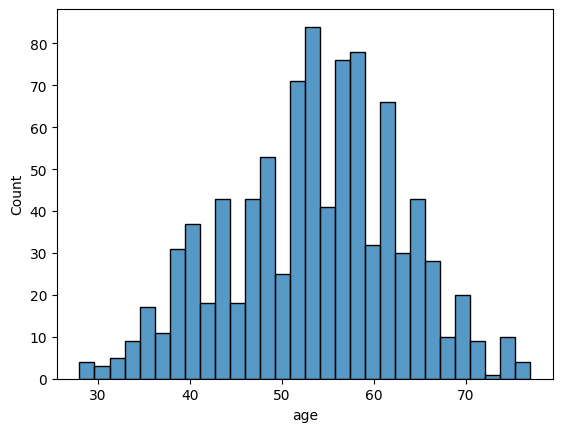

In [37]:
sns.histplot(df["age"], bins=30)
print(df["age"].value_counts())
plt.show()


# PLOTS

## 🔥 Complete EDA Plots for Healthcare Dataset

### 1️⃣ Target Distribution Plot

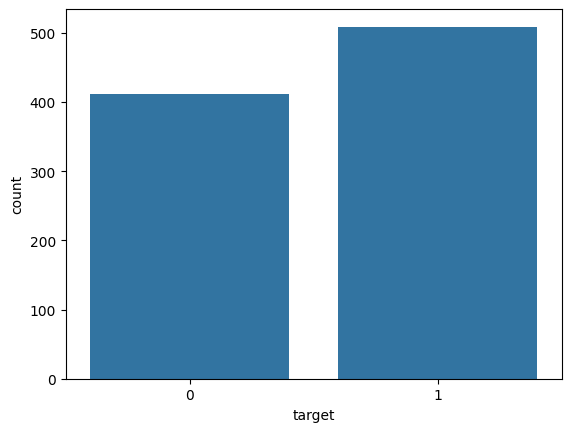

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = "target" , data=df)
plt.show()

📊 Kya dikhata hai

Kitne patients ko heart disease hai

Kitne ko nahi hai

Example:

Target	Meaning
0	No disease
1	Disease
🎯 Purpose

Check class imbalance

Agar:

0 → 900
1 → 100

To model biased ho sakta hai.

## Age Distribution

age
54    51
58    43
55    41
56    38
57    38
52    36
59    35
51    35
62    35
53    33
60    32
61    31
48    31
63    30
50    25
41    24
43    24
46    24
49    22
64    22
65    21
44    19
47    19
42    18
45    18
38    16
67    15
39    15
40    13
66    13
69    13
37    11
35    11
68    10
74     7
34     7
70     7
36     6
71     5
32     5
72     4
29     3
75     3
31     2
77     2
76     2
33     2
28     1
30     1
73     1
Name: count, dtype: int64


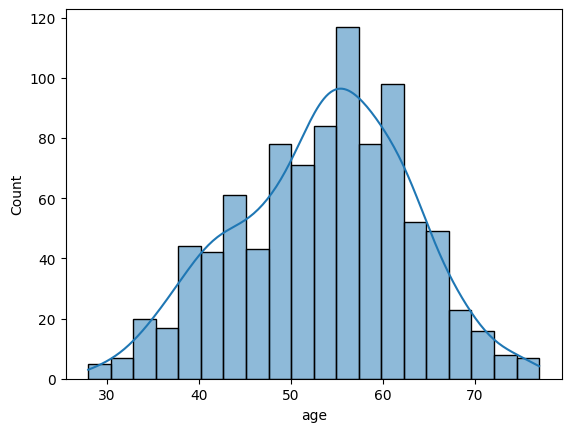

In [40]:
sns.histplot(df["age"] , bins = 20 , kde=True)
print(df["age"].value_counts())
plt.show()



📊 Kya dikhata hai

Dataset me patients kis age group ke zyada hain

Example:

Most patients → 50-60

🎯 Purpose

Understand data distribution

## Gender Distribution

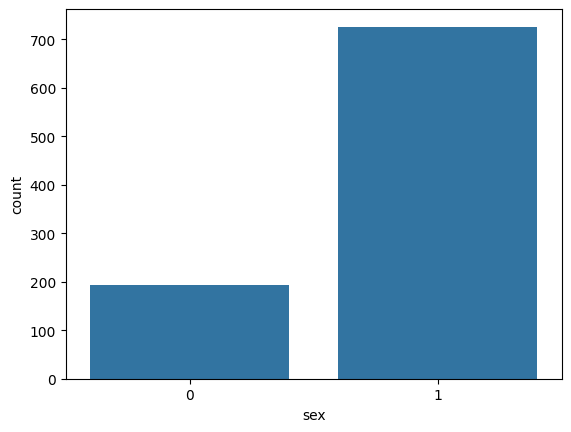

In [41]:
sns.countplot(x = "sex" , data=df)
plt.show()

## Age vs Disease

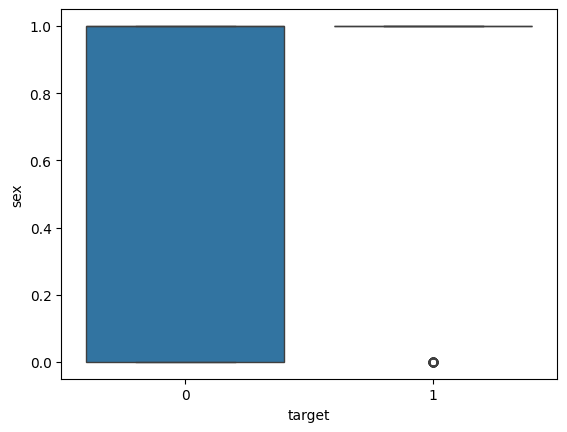

In [43]:
sns.boxplot(x = "target" , y = "sex" , data=df)
plt.show()

## Chest apin Type vs Disease

In [48]:
df.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'ca', 'target', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

In [46]:
sns.countplot(x="cp", y="target", data=df)
plt.show()

TypeError: Cannot pass values for both `x` and `y`.

# 8️⃣ Correlation Heatmap (Most Important)

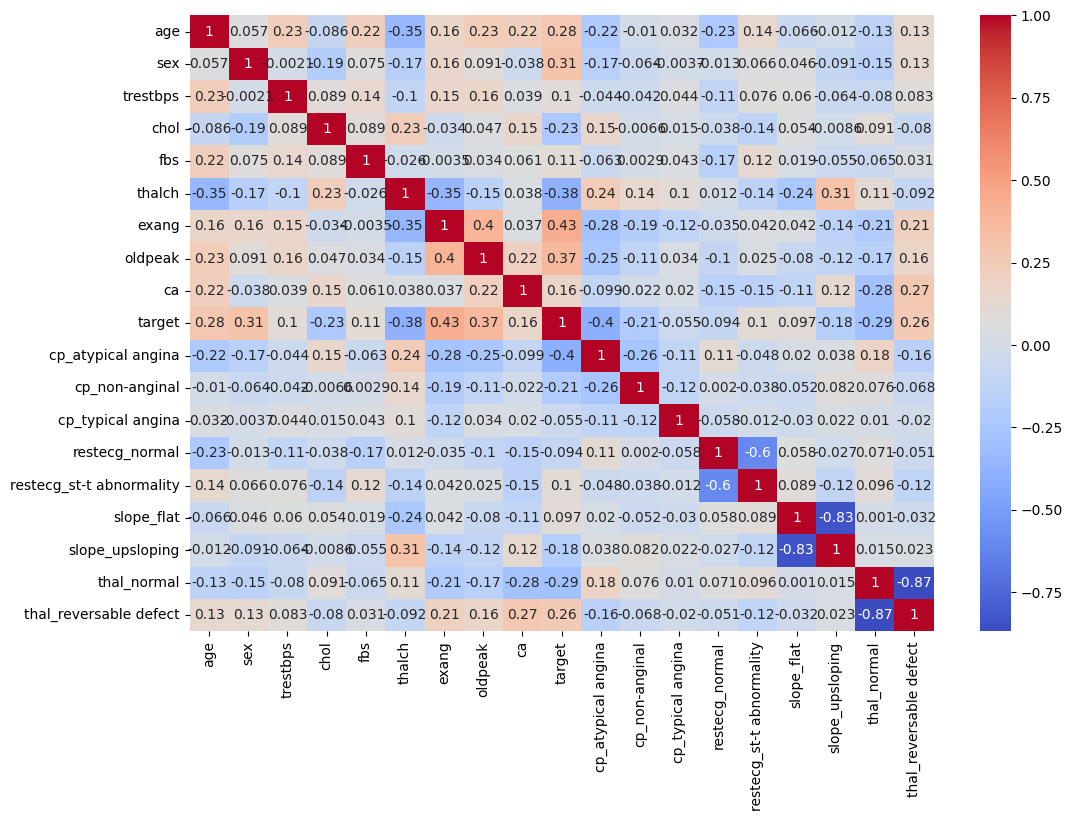

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Scatter plot

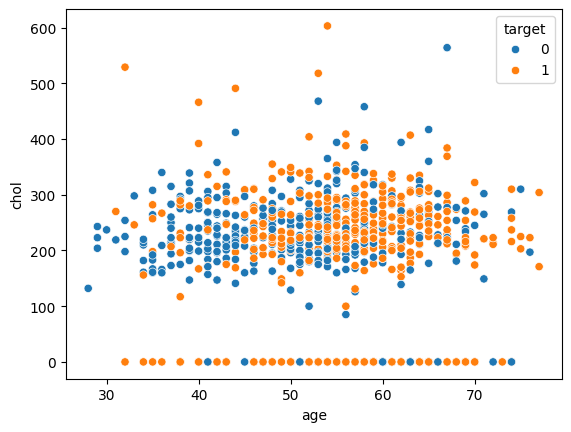

In [50]:
sns.scatterplot(x="age", y="chol", hue="target", data=df)
plt.show()

# 🔟 Outlier Detection

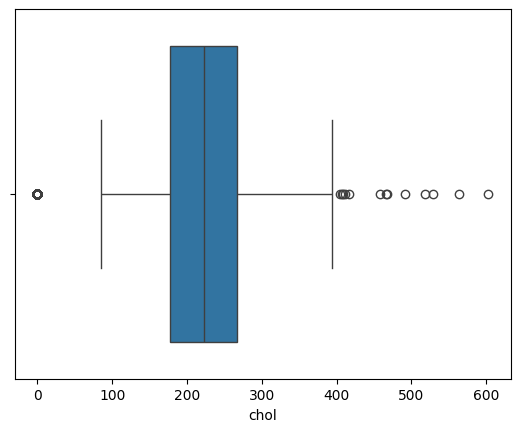

In [51]:
sns.boxplot(x=df["chol"])
plt.show()